# Part 2a: Custom Learning Rate Schedulers

This notebook demonstrates how to create custom learning rate schedulers in TensorFlow/Keras and PyTorch.

## Topics Covered:
1. OneCycleLR Scheduler
2. Cosine Annealing with Warm Restarts
3. Custom Exponential Decay
4. Learning Rate Finder

**Author:** Advanced Deep Learning Course Assignment

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Part A: Custom LR Schedulers in TensorFlow/Keras

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.19.0


In [20]:
# Load data
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train[:10000]
y_train = y_train[:10000]

In [21]:
def create_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    return model

## 1. OneCycleLR Scheduler

The OneCycle learning rate policy increases LR from initial to max, then decreases to minimum in a cosine curve. This achieves superconvergence.

In [22]:
class OneCycleScheduler(callbacks.Callback):
    """
    OneCycle Learning Rate Scheduler.

    Based on the paper "Super-Convergence: Very Fast Training of Neural Networks
    Using Large Learning Rates" by Leslie Smith.

    The learning rate follows a cosine curve:
    - Phase 1: Warmup from initial_lr to max_lr
    - Phase 2: Annealing from max_lr to min_lr
    """
    def __init__(self, max_lr, steps_per_epoch, epochs,
                 pct_start=0.3, div_factor=25, final_div_factor=1e4):
        super().__init__()
        self.max_lr = max_lr
        self.total_steps = steps_per_epoch * epochs
        self.pct_start = pct_start
        self.div_factor = div_factor
        self.final_div_factor = final_div_factor

        self.initial_lr = max_lr / div_factor
        self.min_lr = max_lr / final_div_factor
        self.step_num = 0
        self.history = {'lr': [], 'loss': []}

    def on_train_batch_begin(self, batch, logs=None):
        # Calculate learning rate for current step
        pct = self.step_num / self.total_steps

        if pct <= self.pct_start:
            # Warmup phase: linear increase
            progress = pct / self.pct_start
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * progress
        else:
            # Annealing phase: cosine decay
            progress = (pct - self.pct_start) / (1 - self.pct_start)
            lr = self.min_lr + (self.max_lr - self.min_lr) * (1 + np.cos(np.pi * progress)) / 2

        # Keras 3.x compatible: use learning_rate.assign() instead of backend.set_value
        self.model.optimizer.learning_rate.assign(lr)
        self.history['lr'].append(lr)

    def on_train_batch_end(self, batch, logs=None):
        self.step_num += 1
        if logs:
            self.history['loss'].append(logs.get('loss', 0))

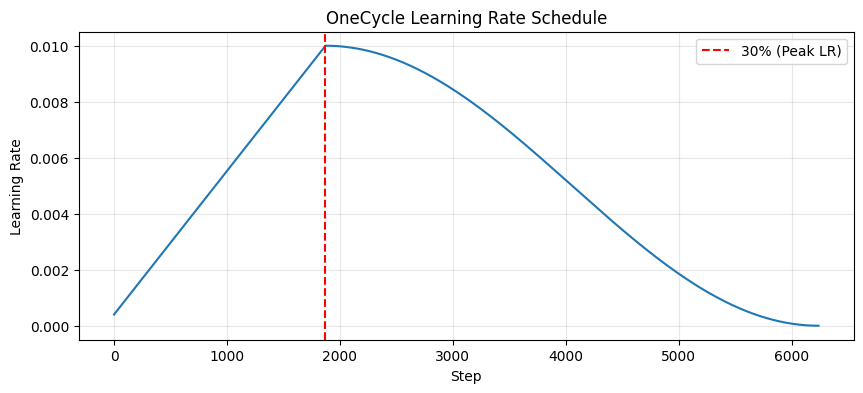

In [23]:
# Visualize OneCycle schedule before training
epochs = 20
steps_per_epoch = len(X_train) // 32
total_steps = epochs * steps_per_epoch

scheduler = OneCycleScheduler(
    max_lr=0.01,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs
)

# Simulate LR schedule
lrs = []
for step in range(total_steps):
    pct = step / total_steps
    if pct <= 0.3:
        progress = pct / 0.3
        lr = 0.01/25 + (0.01 - 0.01/25) * progress
    else:
        progress = (pct - 0.3) / 0.7
        lr = 0.01/1e4 + (0.01 - 0.01/1e4) * (1 + np.cos(np.pi * progress)) / 2
    lrs.append(lr)

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.axvline(x=int(total_steps * 0.3), color='r', linestyle='--', label='30% (Peak LR)')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('OneCycle Learning Rate Schedule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# Train with OneCycle
print("Training with OneCycle Scheduler...")
model_onecycle = create_model()
model_onecycle.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

onecycle_scheduler = OneCycleScheduler(
    max_lr=0.1,
    steps_per_epoch=len(X_train) // 32,
    epochs=15
)

history_onecycle = model_onecycle.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[onecycle_scheduler],
    verbose=1
)

Training with OneCycle Scheduler...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6065 - loss: 1.0833 - val_accuracy: 0.7505 - val_loss: 0.6555
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7243 - loss: 0.7454 - val_accuracy: 0.7605 - val_loss: 0.6214
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7294 - loss: 0.7367 - val_accuracy: 0.7290 - val_loss: 0.7239
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6902 - loss: 0.8432 - val_accuracy: 0.7235 - val_loss: 0.8090
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6635 - loss: 0.9207 - val_accuracy: 0.6965 - val_loss: 0.7511
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6199 - loss: 1.0399 - val_accuracy: 0.6705 - val_loss: 0.9154
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5508 - loss: 1.2482 - val_accuracy: 0.6710 - val_loss: 0.8607
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5

## 2. Cosine Annealing with Warm Restarts

In [25]:
class CosineAnnealingWarmRestarts(keras.optimizers.schedules.LearningRateSchedule):
    """
    Cosine Annealing with Warm Restarts.

    Based on SGDR: Stochastic Gradient Descent with Warm Restarts.
    The LR follows a cosine curve and restarts at specified intervals.
    """
    def __init__(self, initial_learning_rate, T_0, T_mult=1, eta_min=0):
        super().__init__()
        self.initial_lr = initial_learning_rate
        self.T_0 = T_0          # Initial restart interval
        self.T_mult = T_mult     # Multiplier for restart interval
        self.eta_min = eta_min   # Minimum learning rate

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        T_0 = tf.cast(self.T_0, tf.float32)
        T_mult = tf.cast(self.T_mult, tf.float32)

        # Use tf.cond instead of Python if for graph compatibility
        def simple_case():
            # Fixed intervals (T_mult == 1)
            T_cur = tf.math.floormod(step, T_0)
            T_i = T_0
            return T_cur, T_i

        def geometric_case():
            # Geometric increase in intervals
            n = tf.math.floor(tf.math.log(step / T_0 * (T_mult - 1) + 1) / tf.math.log(T_mult))
            T_i = T_0 * (T_mult ** n)
            T_cur = step - T_0 * (T_mult ** n - 1) / (T_mult - 1)
            return T_cur, T_i

        T_cur, T_i = tf.cond(
            tf.equal(T_mult, 1.0),
            simple_case,
            geometric_case
        )

        # Cosine annealing
        lr = self.eta_min + (self.initial_lr - self.eta_min) * (
            1 + tf.cos(np.pi * T_cur / T_i)
        ) / 2

        return lr

    def get_config(self):
        return {
            'initial_learning_rate': self.initial_lr,
            'T_0': self.T_0,
            'T_mult': self.T_mult,
            'eta_min': self.eta_min
        }

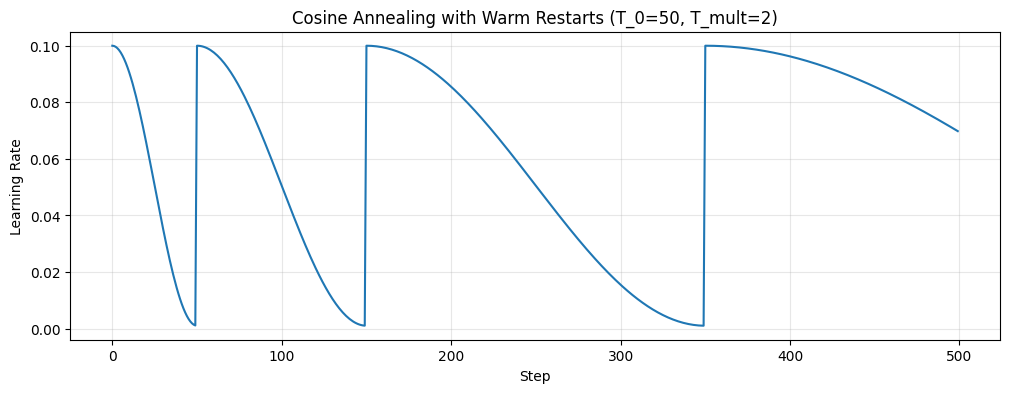

In [26]:
# Visualize Cosine Annealing with Warm Restarts
schedule = CosineAnnealingWarmRestarts(
    initial_learning_rate=0.1,
    T_0=50,
    T_mult=2,
    eta_min=0.001
)

steps = range(500)
lrs = [schedule(step).numpy() for step in steps]

plt.figure(figsize=(12, 4))
plt.plot(lrs)
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Cosine Annealing with Warm Restarts (T_0=50, T_mult=2)')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Train with Cosine Annealing Warm Restarts
print("Training with Cosine Annealing Warm Restarts...")
model_cosine = create_model()

cosine_schedule = CosineAnnealingWarmRestarts(
    initial_learning_rate=0.01,
    T_0=100,
    T_mult=2,
    eta_min=0.0001
)

model_cosine.compile(
    optimizer=keras.optimizers.SGD(learning_rate=cosine_schedule, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cosine = model_cosine.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Training with Cosine Annealing Warm Restarts...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6285 - loss: 1.0283 - val_accuracy: 0.7540 - val_loss: 0.6567
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7435 - loss: 0.6987 - val_accuracy: 0.7815 - val_loss: 0.5680
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7930 - loss: 0.5926 - val_accuracy: 0.7835 - val_loss: 0.5732
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7899 - loss: 0.5720 - val_accuracy: 0.8155 - val_loss: 0.4930
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8207 - loss: 0.4987 - val_accuracy: 0.8315 - val_loss: 0.4637
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8401 - loss: 0.4594 - val_accuracy: 0.8380 - val_loss: 0.4432
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8204 - loss: 0.4996 - val_accuracy: 0.8300 - val_loss: 0.4714
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - ac

## 3. Custom Exponential Decay with Warmup

In [28]:
class WarmupExponentialDecay(keras.optimizers.schedules.LearningRateSchedule):
    """
    Learning rate schedule with linear warmup followed by exponential decay.
    """
    def __init__(self, initial_learning_rate, warmup_steps, decay_steps, decay_rate):
        super().__init__()
        self.initial_lr = initial_learning_rate
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps
        self.decay_rate = decay_rate

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)

        # Linear warmup
        warmup_lr = self.initial_lr * (step / warmup_steps)

        # Exponential decay
        decay_step = step - warmup_steps
        decayed_lr = self.initial_lr * (self.decay_rate ** (decay_step / self.decay_steps))

        # Choose based on step
        lr = tf.cond(step < warmup_steps, lambda: warmup_lr, lambda: decayed_lr)

        return lr

    def get_config(self):
        return {
            'initial_learning_rate': self.initial_lr,
            'warmup_steps': self.warmup_steps,
            'decay_steps': self.decay_steps,
            'decay_rate': self.decay_rate
        }

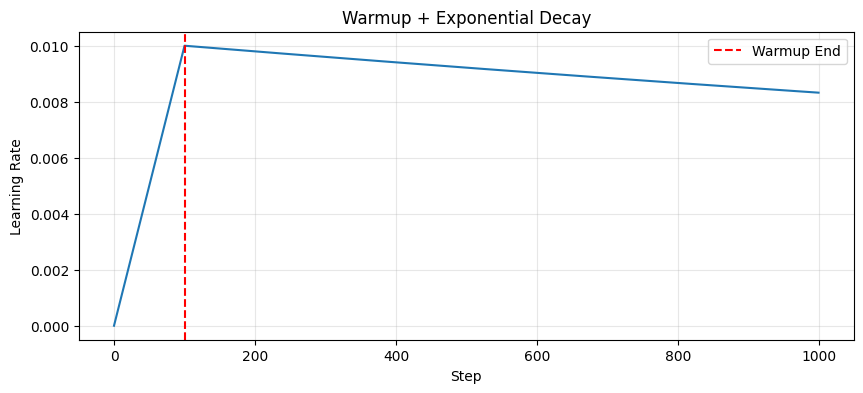

In [29]:
# Visualize
warmup_schedule = WarmupExponentialDecay(
    initial_learning_rate=0.01,
    warmup_steps=100,
    decay_steps=200,
    decay_rate=0.96
)

steps = range(1000)
lrs = [warmup_schedule(step).numpy() for step in steps]

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.axvline(x=100, color='r', linestyle='--', label='Warmup End')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Warmup + Exponential Decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Part B: Custom LR Schedulers in PyTorch

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler, LambdaLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

PyTorch version: 2.10.0+cu128


In [14]:
# PyTorch OneCycleLR (custom implementation)
class OneCycleLRPyTorch(_LRScheduler):
    """
    OneCycle Learning Rate Scheduler for PyTorch.
    """
    def __init__(self, optimizer, max_lr, total_steps, pct_start=0.3,
                 div_factor=25, final_div_factor=1e4, last_epoch=-1):
        self.max_lr = max_lr
        self.total_steps = total_steps
        self.pct_start = pct_start
        self.div_factor = div_factor
        self.final_div_factor = final_div_factor

        self.initial_lr = max_lr / div_factor
        self.min_lr = max_lr / final_div_factor

        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch
        pct = step / self.total_steps

        if pct <= self.pct_start:
            # Warmup phase
            progress = pct / self.pct_start
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * progress
        else:
            # Annealing phase
            progress = (pct - self.pct_start) / (1 - self.pct_start)
            lr = self.min_lr + (self.max_lr - self.min_lr) * (1 + np.cos(np.pi * progress)) / 2

        return [lr for _ in self.base_lrs]

In [15]:
# PyTorch CosineAnnealingWarmRestarts (custom)
class CosineAnnealingWarmRestartsPyTorch(_LRScheduler):
    """
    Cosine Annealing with Warm Restarts for PyTorch.
    """
    def __init__(self, optimizer, T_0, T_mult=1, eta_min=0, last_epoch=-1):
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.T_i = T_0
        self.T_cur = 0
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [
            self.eta_min + (base_lr - self.eta_min) *
            (1 + np.cos(np.pi * self.T_cur / self.T_i)) / 2
            for base_lr in self.base_lrs
        ]

    def step(self, epoch=None):
        if epoch is None:
            epoch = self.last_epoch + 1
            self.T_cur += 1

            if self.T_cur >= self.T_i:
                self.T_cur = 0
                self.T_i = self.T_i * self.T_mult
        else:
            self.T_cur = epoch

        self.last_epoch = epoch

        for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
            param_group['lr'] = lr

In [16]:
# Create PyTorch model
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

# Test custom schedulers
model = SimpleNet()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# OneCycle
onecycle = OneCycleLRPyTorch(optimizer, max_lr=0.1, total_steps=1000)

# Cosine with restarts
cosine_restart = CosineAnnealingWarmRestartsPyTorch(optimizer, T_0=100, T_mult=2)

print("PyTorch custom schedulers created successfully!")

PyTorch custom schedulers created successfully!


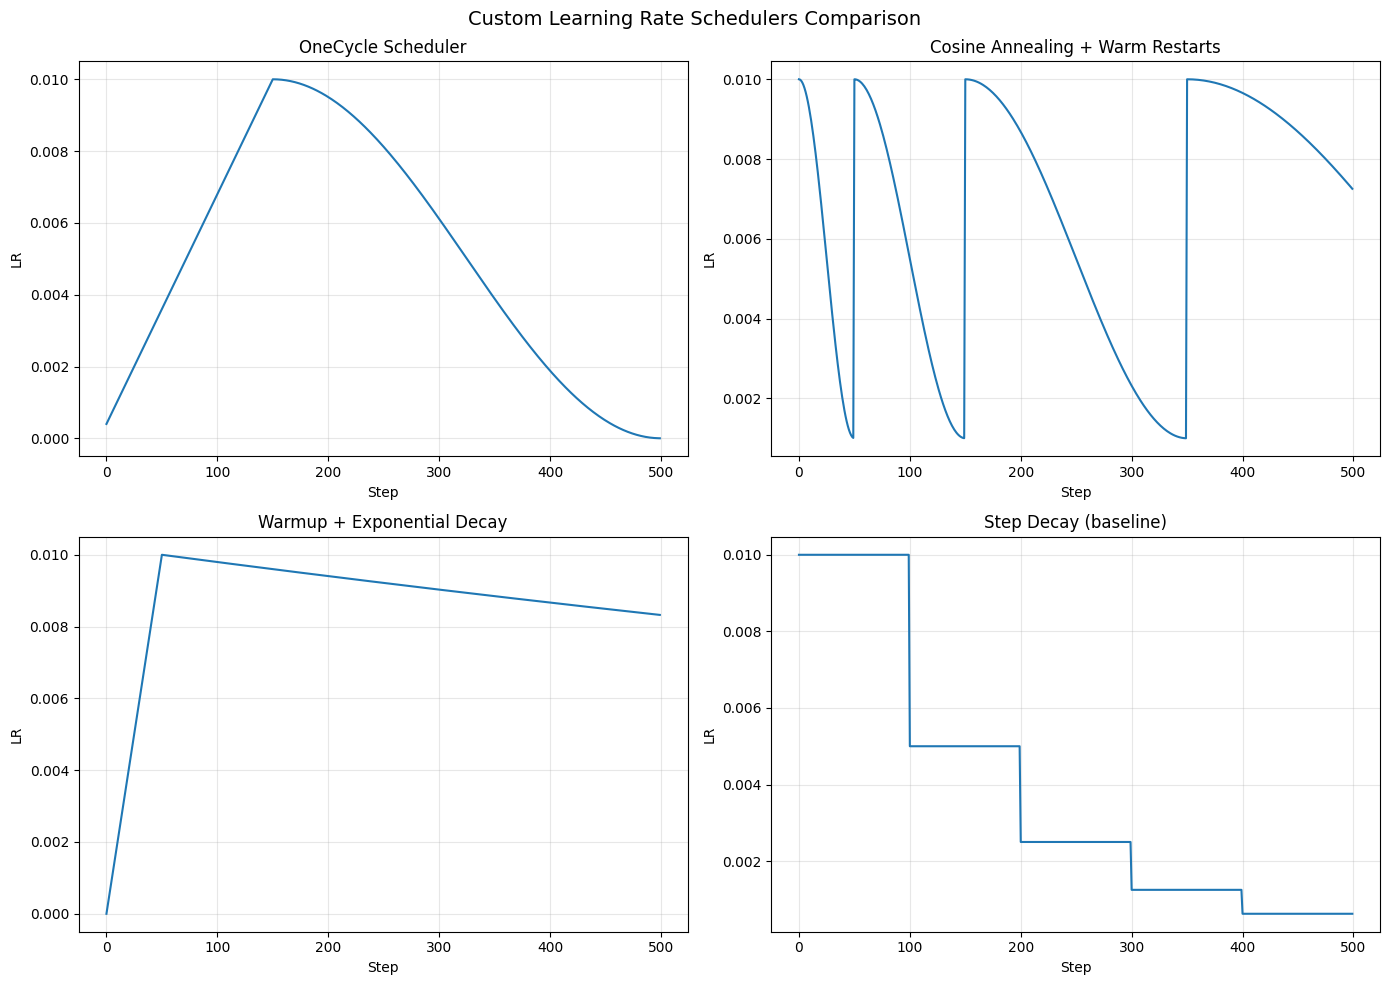

In [17]:
# Compare all schedulers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Custom Learning Rate Schedulers Comparison', fontsize=14)

# OneCycle (TensorFlow)
steps = range(500)
lrs_onecycle = []
for step in steps:
    pct = step / 500
    if pct <= 0.3:
        lr = 0.01/25 + (0.01 - 0.01/25) * (pct / 0.3)
    else:
        progress = (pct - 0.3) / 0.7
        lr = 0.01/1e4 + (0.01 - 0.01/1e4) * (1 + np.cos(np.pi * progress)) / 2
    lrs_onecycle.append(lr)

axes[0, 0].plot(lrs_onecycle)
axes[0, 0].set_title('OneCycle Scheduler')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('LR')
axes[0, 0].grid(True, alpha=0.3)

# Cosine Warm Restarts
lrs_cosine = [CosineAnnealingWarmRestarts(0.01, 50, 2, 0.001)(step).numpy() for step in range(500)]
axes[0, 1].plot(lrs_cosine)
axes[0, 1].set_title('Cosine Annealing + Warm Restarts')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('LR')
axes[0, 1].grid(True, alpha=0.3)

# Warmup + Exponential
lrs_warmup = [WarmupExponentialDecay(0.01, 50, 100, 0.96)(step).numpy() for step in range(500)]
axes[1, 0].plot(lrs_warmup)
axes[1, 0].set_title('Warmup + Exponential Decay')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('LR')
axes[1, 0].grid(True, alpha=0.3)

# Standard step decay for comparison
lrs_step = [0.01 * (0.5 ** (step // 100)) for step in range(500)]
axes[1, 1].plot(lrs_step)
axes[1, 1].set_title('Step Decay (baseline)')
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('LR')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

### Custom LR Schedulers:

| Scheduler | Description | Best For |
|-----------|-------------|----------|
| **OneCycleLR** | Warmup + cosine decay | Fast training, superconvergence |
| **CosineWarmRestarts** | Periodic cosine restarts | Long training, avoiding local minima |
| **WarmupExponential** | Linear warmup + exp decay | Transformers, large models |

### Implementation Tips:
- TensorFlow: Subclass `LearningRateSchedule` or use `Callback`
- PyTorch: Subclass `_LRScheduler`
- Always visualize schedule before training